# MVP — Engenharia de Dados

## Análise de Acidentes em Rodovias Federais Brasileiras

Este projeto tem como objetivo construir um pipeline de dados em nuvem para coletar, armazenar, tratar, modelar e analisar dados públicos sobre acidentes ocorridos em rodovias federais brasileiras.

Serão utilizados dados da Polícia Rodoviária Federal (PRF), referentes ao período de 2017 a 2025, complementados por dados de feriados nacionais disponibilizados pela ANBIMA.

O pipeline será desenvolvido na plataforma Databricks utilizando uma arquitetura em camadas Bronze, Silver e Gold.


In [0]:
spark.sql("""
CREATE SCHEMA IF NOT EXISTS workspace.mvp_prf
""")

spark.sql("""
SHOW SCHEMAS IN workspace
""").show()

+------------------+
|      databaseName|
+------------------+
|           default|
|information_schema|
|           mvp_prf|
+------------------+



In [0]:
spark.sql("""
USE CATALOG workspace
""")

spark.sql("""
USE SCHEMA mvp_prf
""")

spark.sql("""
SELECT current_catalog(), current_schema()
""").show()

+-----------------+----------------+
|current_catalog()|current_schema()|
+-----------------+----------------+
|        workspace|         mvp_prf|
+-----------------+----------------+



In [0]:
spark.sql("""
CREATE VOLUME IF NOT EXISTS workspace.mvp_prf.dados
""")

spark.sql("""
SHOW VOLUMES IN workspace.mvp_prf
""").show()

+--------+-----------+
|database|volume_name|
+--------+-----------+
| mvp_prf|      dados|
+--------+-----------+



In [0]:
dbutils.fs.mkdirs("/Volumes/workspace/mvp_prf/dados/bronze/prf")
dbutils.fs.mkdirs("/Volumes/workspace/mvp_prf/dados/bronze/feriados")

True

In [0]:
display(
    dbutils.fs.ls("/Volumes/workspace/mvp_prf/dados/bronze/")
)

path,name,size,modificationTime
dbfs:/Volumes/workspace/mvp_prf/dados/bronze/feriados/,feriados/,0,1790237201890
dbfs:/Volumes/workspace/mvp_prf/dados/bronze/prf/,prf/,0,1790237201890


## 2. Coleta e armazenamento dos dados

### 2.1 Dados de acidentes da PRF

Os dados de acidentes são disponibilizados pela Polícia Rodoviária Federal em arquivos anuais. Para o período analisado serão utilizados os arquivos de 2017 a 2025, agrupados por ocorrência.

A coleta será realizada diretamente a partir dos arquivos disponibilizados pela fonte, com armazenamento dos dados originais na camada Bronze do ambiente Databricks.

Inicialmente será realizada a ingestão do arquivo de 2017 para validação do processo. Após a validação, o procedimento será aplicado aos demais anos.

In [0]:
import requests

file_id = "1HPLWt5f_l4RIX3tKjI4tUXyZOev52W0N"
url = f"https://drive.usercontent.google.com/download?id={file_id}&export=download&confirm=t"

arquivo_temporario = "/tmp/prf_2017.zip"

response = requests.get(url, timeout=120)

print("Status HTTP:", response.status_code)
print("Tamanho recebido:", len(response.content), "bytes")
print("Content-Type:", response.headers.get("Content-Type"))

Status HTTP: 200
Tamanho recebido: 4248009 bytes
Content-Type: application/octet-stream


In [0]:
arquivo_temporario = "/tmp/prf_2017.zip"

with open(arquivo_temporario, "wb") as f:
    f.write(response.content)

print("Arquivo salvo em:", arquivo_temporario)


Arquivo salvo em: /tmp/prf_2017.zip


In [0]:
import zipfile

print("É um arquivo ZIP válido?", zipfile.is_zipfile(arquivo_temporario))

É um arquivo ZIP válido? True


In [0]:
with zipfile.ZipFile(arquivo_temporario, "r") as z:
    print("Arquivos dentro do ZIP:")
    for nome in z.namelist():
        print(nome)

Arquivos dentro do ZIP:
datatran2017.csv


In [0]:
import zipfile
import os
import shutil

arquivo_temporario = "/tmp/prf_2017.zip"
pasta_extracao = "/tmp/prf_2017"
destino_bronze = "/Volumes/workspace/mvp_prf/dados/bronze/prf/datatran2017.csv"

os.makedirs(pasta_extracao, exist_ok=True)

with zipfile.ZipFile(arquivo_temporario, "r") as z:
    z.extractall(pasta_extracao)

arquivo_csv = os.path.join(pasta_extracao, "datatran2017.csv")

shutil.copy2(arquivo_csv, destino_bronze)

print("Arquivo gravado na Bronze:")
print(destino_bronze)

Arquivo gravado na Bronze:
/Volumes/workspace/mvp_prf/dados/bronze/prf/datatran2017.csv


In [0]:
df_2017 = (
    spark.read
    .option("header", "true")
    .option("sep", ";")
    .option("inferSchema", "true")
    .csv("/Volumes/workspace/mvp_prf/dados/bronze/prf/datatran2017.csv")
)

print("Quantidade de registros:", df_2017.count())
print("Quantidade de colunas:", len(df_2017.columns))

display(df_2017.limit(5))

Quantidade de registros: 89567
Quantidade de colunas: 30


id,data_inversa,dia_semana,horario,uf,br,km,municipio,causa_acidente,tipo_acidente,classificacao_acidente,fase_dia,sentido_via,condicao_metereologica,tipo_pista,tracado_via,uso_solo,pessoas,mortos,feridos_leves,feridos_graves,ilesos,ignorados,feridos,veiculos,latitude,longitude,regional,delegacia,uop
17,2017-01-01,domingo,01:45:00,RS,116,"34,9",VACARIA,Defeito Mec�nico no Ve�culo,Colis�o traseira,Com V�timas Feridas,Plena Noite,Decrescente,C�u Claro,Simples,Reta,N�o,6,0,4,0,2,0,4,2,"-28,5071196","-50,941176",SPRF-RS,DEL05-RS,UOP03-DEL05-RS
20,2017-01-01,domingo,01:00:00,PR,376,636,TIJUCAS DO SUL,Velocidade Incompat�vel,Sa�da de leito carro��vel,Com V�timas Fatais,Plena Noite,Crescente,Garoa/Chuvisco,Dupla,Curva,N�o,2,1,0,0,1,0,0,2,"-25,754","-49,1266",SPRF-PR,DEL01-PR,DEL7/1-UOP08/PR
69,2017-01-01,domingo,04:40:00,BA,101,65,ENTRE RIOS,Condutor Dormindo,Colis�o frontal,Com V�timas Fatais,Amanhecer,Decrescente,Nublado,Simples,Curva,N�o,5,1,1,1,2,0,2,2,"-11,9618","-38,0953",SPRF-BA,DEL01-BA,UOP04-DEL01-BA
106,2017-01-01,domingo,06:30:00,PA,316,"72,5",CASTANHAL,Falta de Aten��o � Condu��o,Colis�o lateral,Com V�timas Fatais,Amanhecer,Decrescente,C�u Claro,Simples,Reta,N�o,4,1,0,0,3,0,0,3,"-1,2899799","-47,83483207",SPRF-PA,DEL01-PA,DEL19/1-UOP02/PA
109,2017-01-01,domingo,09:00:00,GO,20,"220,5",POSSE,Defeito na Via,Colis�o com objeto est�tico,NA,Pleno dia,Decrescente,C�u Claro,Simples,Declive,N�o,4,0,2,1,0,1,3,2,"-14,14220931","-46,32258922",SPRF-DF,DEL02-DF,UOP03-DEL02-DF


In [0]:
df_2017_latin1 = (
    spark.read
    .option("header", "true")
    .option("sep", ";")
    .option("encoding", "ISO-8859-1")
    .option("inferSchema", "true")
    .csv("/Volumes/workspace/mvp_prf/dados/bronze/prf/datatran2017.csv")
)

display(
    df_2017_latin1
    .select("causa_acidente", "tipo_acidente", "classificacao_acidente")
    .limit(20)
)

causa_acidente,tipo_acidente,classificacao_acidente
Defeito Mecânico no Veículo,Colisão traseira,Com Vítimas Feridas
Velocidade Incompatível,Saída de leito carroçável,Com Vítimas Fatais
Condutor Dormindo,Colisão frontal,Com Vítimas Fatais
Falta de Atenção à Condução,Colisão lateral,Com Vítimas Fatais
Defeito na Via,Colisão com objeto estático,NA
Ingestão de Álcool,Colisão frontal,Com Vítimas Fatais
Não guardar distância de segurança,Colisão traseira,Com Vítimas Feridas
Condutor Dormindo,Colisão lateral,Sem Vítimas
Defeito Mecânico no Veículo,Tombamento,Com Vítimas Feridas
Ingestão de Álcool,Colisão frontal,Com Vítimas Fatais


### 2.2 Ingestão automatizada dos arquivos anuais

Após a validação da coleta e armazenamento do arquivo referente a 2017, o processo foi automatizado para realizar a ingestão dos demais arquivos anuais da PRF.

Os arquivos são obtidos diretamente a partir dos endereços disponibilizados pela fonte, descompactados no ambiente Databricks e armazenados em seu formato CSV original na camada Bronze.

Essa abordagem mantém os dados brutos preservados e permite que as etapas posteriores de tratamento sejam realizadas de forma reproduzível.

In [0]:
import requests
import zipfile
import os
import shutil

arquivos_prf = {
    2018: "1cM4IgGMIiR-u4gBIH5IEe3DcvBvUzedi",
    2019: "1pN3fn2wY34GH6cY-gKfbxRJJBFE0lb_l",
    2020: "1esu6IiH5TVTxFoedv6DBGDd01Gvi8785",
    2021: "12xH8LX9aN2gObR766YN3cMcuycwyCJDz",
    2022: "1PRQjuV5gOn_nn6UNvaJyVURDIfbSAK4-",
    2023: "1-WO3SfNrwwZ5_l7fRTiwBKRw7mi1-HUq",
    2024: "14lB0vqMFkaZj8HZ44b0njYgxs9nAN8KO",
    2025: "1-G3MdmHBt6CprDwcW99xxC4BZ2DU5ryR"
}

destino_bronze = "/Volumes/workspace/mvp_prf/dados/bronze/prf"

for ano, file_id in arquivos_prf.items():

    print(f"\nProcessando {ano}...")

    url = (
        f"https://drive.usercontent.google.com/download"
        f"?id={file_id}&export=download&confirm=t"
    )

    # Download
    response = requests.get(url, timeout=120)
    response.raise_for_status()

    arquivo_zip = f"/tmp/prf_{ano}.zip"

    with open(arquivo_zip, "wb") as f:
        f.write(response.content)

    # Validação
    if not zipfile.is_zipfile(arquivo_zip):
        raise ValueError(f"O arquivo de {ano} não é um ZIP válido.")

    # Extrair
    pasta_extracao = f"/tmp/prf_{ano}"
    os.makedirs(pasta_extracao, exist_ok=True)

    with zipfile.ZipFile(arquivo_zip, "r") as z:
        arquivos_csv = [
            nome for nome in z.namelist()
            if nome.lower().endswith(".csv")
        ]

        if len(arquivos_csv) != 1:
            raise ValueError(
                f"{ano}: esperado 1 CSV, encontrados {len(arquivos_csv)}."
            )

        z.extractall(pasta_extracao)

    origem_csv = os.path.join(
        pasta_extracao,
        arquivos_csv[0]
    )

    destino_csv = os.path.join(
        destino_bronze,
        f"datatran{ano}.csv"
    )

    shutil.copy2(origem_csv, destino_csv)

    print(
        f"{ano}: OK - {len(response.content):,} bytes - "
        f"{arquivos_csv[0]}"
    )

print("\nIngestão concluída.")


Processando 2018...
2018: OK - 3,294,461 bytes - datatran2018.csv

Processando 2019...
2019: OK - 3,237,669 bytes - datatran2019.csv

Processando 2020...
2020: OK - 3,075,980 bytes - datatran2020.csv

Processando 2021...
2021: OK - 3,217,660 bytes - datatran2021.csv

Processando 2022...
2022: OK - 3,227,721 bytes - datatran2022.csv

Processando 2023...
2023: OK - 3,397,281 bytes - datatran2023.csv

Processando 2024...
2024: OK - 3,783,609 bytes - datatran2024.csv

Processando 2025...
2025: OK - 3,727,148 bytes - datatran2025.csv

Ingestão concluída.


In [0]:
arquivos_bronze = dbutils.fs.ls(
    "/Volumes/workspace/mvp_prf/dados/bronze/prf/"
)

display(arquivos_bronze)

path,name,size,modificationTime
dbfs:/Volumes/workspace/mvp_prf/dados/bronze/prf/datatran2017.csv,datatran2017.csv,24887945,1790237212000
dbfs:/Volumes/workspace/mvp_prf/dados/bronze/prf/datatran2018.csv,datatran2018.csv,19481431,1790237231000
dbfs:/Volumes/workspace/mvp_prf/dados/bronze/prf/datatran2019.csv,datatran2019.csv,19101686,1790237234000
dbfs:/Volumes/workspace/mvp_prf/dados/bronze/prf/datatran2020.csv,datatran2020.csv,18042979,1790237237000
dbfs:/Volumes/workspace/mvp_prf/dados/bronze/prf/datatran2021.csv,datatran2021.csv,18675025,1790237245000
dbfs:/Volumes/workspace/mvp_prf/dados/bronze/prf/datatran2022.csv,datatran2022.csv,18723306,1790237254000
dbfs:/Volumes/workspace/mvp_prf/dados/bronze/prf/datatran2023.csv,datatran2023.csv,19770946,1790237263000
dbfs:/Volumes/workspace/mvp_prf/dados/bronze/prf/datatran2024.csv,datatran2024.csv,21365616,1790237266000
dbfs:/Volumes/workspace/mvp_prf/dados/bronze/prf/datatran2025.csv,datatran2025.csv,21143436,1790237269000


### 2.3 Ingestão do calendário de feriados

Para complementar os dados de acidentes, foi incorporada uma segunda fonte contendo o calendário de feriados nacionais disponibilizado pela ANBIMA.

O arquivo é disponibilizado em formato XLS e será coletado diretamente da fonte e armazenado sem alterações na camada Bronze.

Posteriormente, na camada Silver, serão selecionados os registros referentes ao período de 2017 a 2025, padronizados os campos necessários e realizada a integração com os dados de acidentes por meio da data da ocorrência.

In [0]:
import requests

url_feriados = "https://www.anbima.com.br/feriados/arqs/feriados_nacionais.xls"

response = requests.get(url_feriados, timeout=120)
response.raise_for_status()

print("Status HTTP:", response.status_code)
print("Tamanho recebido:", len(response.content), "bytes")
print("Content-Type:", response.headers.get("Content-Type"))

Status HTTP: 200
Tamanho recebido: 111104 bytes
Content-Type: application/vnd.ms-excel


In [0]:
destino_feriados = "/Volumes/workspace/mvp_prf/dados/bronze/feriados/feriados_nacionais.xls"

with open(destino_feriados, "wb") as f:
    f.write(response.content)

print("Arquivo gravado em:")
print(destino_feriados)

Arquivo gravado em:
/Volumes/workspace/mvp_prf/dados/bronze/feriados/feriados_nacionais.xls


## 3. Preparação e qualidade dos dados

### 3.1 Validação estrutural dos arquivos da PRF

Antes da consolidação dos dados, foi realizada uma validação dos arquivos anuais da PRF para verificar a quantidade de registros, quantidade de atributos e compatibilidade dos esquemas.

Essa etapa permite identificar eventuais alterações na estrutura da fonte ao longo do período analisado antes da construção da camada Silver.

In [0]:
from pyspark.sql import functions as F

caminho_prf = "/Volumes/workspace/mvp_prf/dados/bronze/prf/"

resumo_arquivos = []
schemas = {}

for ano in range(2017, 2026):

    caminho = f"{caminho_prf}datatran{ano}.csv"

    df = (
        spark.read
        .option("header", "true")
        .option("sep", ";")
        .option("encoding", "ISO-8859-1")
        .option("inferSchema", "true")
        .csv(caminho)
    )

    resumo_arquivos.append(
        (ano, df.count(), len(df.columns))
    )

    schemas[ano] = df.columns

df_resumo = spark.createDataFrame(
    resumo_arquivos,
    ["ano", "registros", "colunas"]
)

display(df_resumo.orderBy("ano"))

ano,registros,colunas
2017,89567,30
2018,69333,30
2019,67558,30
2020,63585,30
2021,64567,30
2022,64606,30
2023,67766,30
2024,73202,30
2025,72529,30


In [0]:
colunas_referencia = schemas[2017]

for ano in range(2017, 2026):

    mesmas_colunas = schemas[ano] == colunas_referencia

    print(
        f"{ano}: "
        f"{'Schema compatível' if mesmas_colunas else 'ATENÇÃO - schema diferente'}"
    )

    if not mesmas_colunas:
        print("  Faltando:", set(colunas_referencia) - set(schemas[ano]))
        print("  Adicionais:", set(schemas[ano]) - set(colunas_referencia))

2017: Schema compatível
2018: Schema compatível
2019: Schema compatível
2020: Schema compatível
2021: Schema compatível
2022: Schema compatível
2023: Schema compatível
2024: Schema compatível
2025: Schema compatível


In [0]:
df_resumo.agg(
    F.sum("registros").alias("total_registros"),
    F.min("ano").alias("ano_inicial"),
    F.max("ano").alias("ano_final")
).show()

+---------------+-----------+---------+
|total_registros|ano_inicial|ano_final|
+---------------+-----------+---------+
|         632713|       2017|     2025|
+---------------+-----------+---------+



### 3.2 Consolidação dos dados de acidentes

Após a validação estrutural, os nove arquivos anuais foram consolidados em uma única base.

Durante essa etapa, os arquivos foram lidos utilizando a codificação ISO-8859-1, necessária para a correta interpretação dos caracteres acentuados presentes nos dados originais.

Também foi acrescentado o atributo `ano_origem`, que identifica o arquivo anual de origem de cada registro e contribui para a rastreabilidade e linhagem dos dados.

A base consolidada constitui o ponto de partida para os tratamentos de qualidade e seleção dos atributos que formarão a camada Silver.

In [0]:
from pyspark.sql import functions as F

caminho_prf = "/Volumes/workspace/mvp_prf/dados/bronze/prf/"

dfs = []

for ano in range(2017, 2026):

    df_ano = (
        spark.read
        .option("header", "true")
        .option("sep", ";")
        .option("encoding", "ISO-8859-1")
        .option("inferSchema", "true")
        .csv(f"{caminho_prf}datatran{ano}.csv")
        .withColumn("ano_origem", F.lit(ano))
    )

    dfs.append(df_ano)

df_prf_consolidado = dfs[0]

for df_ano in dfs[1:]:
    df_prf_consolidado = df_prf_consolidado.unionByName(df_ano)

print("Registros consolidados:", df_prf_consolidado.count())
print("Quantidade de colunas:", len(df_prf_consolidado.columns))

Registros consolidados: 632713
Quantidade de colunas: 31


Limpando a base:

In [0]:
# Seleção das colunas que serão utilizadas na camada Silver

colunas_silver = [
    "id",
    "data_inversa",
    "dia_semana",
    "horario",
    "uf",
    "br",
    "km",
    "municipio",
    "causa_acidente",
    "tipo_acidente",
    "classificacao_acidente",
    "fase_dia",
    "sentido_via",
    "condicao_metereologica",
    "tipo_pista",
    "tracado_via",
    "uso_solo",
    "pessoas",
    "mortos",
    "feridos_leves",
    "feridos_graves",
    "ilesos",
    "feridos",
    "veiculos",
    "latitude",
    "longitude",
    "ano_origem"
]

df_silver = df_prf_consolidado.select(*colunas_silver)

print("Registros:", df_silver.count())
print("Colunas:", len(df_silver.columns))

display(df_silver.limit(10))

Registros: 632713
Colunas: 27


id,data_inversa,dia_semana,horario,uf,br,km,municipio,causa_acidente,tipo_acidente,classificacao_acidente,fase_dia,sentido_via,condicao_metereologica,tipo_pista,tracado_via,uso_solo,pessoas,mortos,feridos_leves,feridos_graves,ilesos,feridos,veiculos,latitude,longitude,ano_origem
17.0,2017-01-01,domingo,01:45:00,RS,116,"34,9",VACARIA,Defeito Mecânico no Veículo,Colisão traseira,Com Vítimas Feridas,Plena Noite,Decrescente,Céu Claro,Simples,Reta,Não,6,0,4,0,2,4,2,"-28,5071196","-50,941176",2017
20.0,2017-01-01,domingo,01:00:00,PR,376,636,TIJUCAS DO SUL,Velocidade Incompatível,Saída de leito carroçável,Com Vítimas Fatais,Plena Noite,Crescente,Garoa/Chuvisco,Dupla,Curva,Não,2,1,0,0,1,0,2,"-25,754","-49,1266",2017
69.0,2017-01-01,domingo,04:40:00,BA,101,65,ENTRE RIOS,Condutor Dormindo,Colisão frontal,Com Vítimas Fatais,Amanhecer,Decrescente,Nublado,Simples,Curva,Não,5,1,1,1,2,2,2,"-11,9618","-38,0953",2017
106.0,2017-01-01,domingo,06:30:00,PA,316,"72,5",CASTANHAL,Falta de Atenção à Condução,Colisão lateral,Com Vítimas Fatais,Amanhecer,Decrescente,Céu Claro,Simples,Reta,Não,4,1,0,0,3,0,3,"-1,2899799","-47,83483207",2017
109.0,2017-01-01,domingo,09:00:00,GO,20,"220,5",POSSE,Defeito na Via,Colisão com objeto estático,NA,Pleno dia,Decrescente,Céu Claro,Simples,Declive,Não,4,0,2,1,0,3,2,"-14,14220931","-46,32258922",2017
112.0,2017-01-01,domingo,07:40:00,RN,405,30,MOSSORO,Ingestão de Álcool,Colisão frontal,Com Vítimas Fatais,Pleno dia,Crescente,Céu Claro,Simples,Reta,Não,3,1,0,0,1,0,5,"-5,3136","-37,569",2017
116.0,2017-01-01,domingo,10:35:00,PR,376,"249,5",APUCARANA,Não guardar distância de segurança,Colisão traseira,Com Vítimas Feridas,Pleno dia,Crescente,Céu Claro,Simples,Curva,Não,5,0,1,0,4,1,2,"-23,61073749","-51,39895052",2017
123.0,2017-01-01,domingo,11:50:00,MG,262,"483,1",BOM DESPACHO,Condutor Dormindo,Colisão lateral,Sem Vítimas,Pleno dia,Crescente,Céu Claro,Simples,Reta,Não,3,0,0,0,2,0,3,"-19,78561818","-45,30956142",2017
129.0,2017-01-01,domingo,10:30:00,MT,364,469,VARZEA GRANDE,Defeito Mecânico no Veículo,Tombamento,Com Vítimas Feridas,Pleno dia,Crescente,Sol,Simples,Aclive;Reta,Não,4,0,3,0,0,3,3,"-15,35686639","-56,41299248",2017
133.0,2017-01-01,domingo,08:30:00,MA,316,375,BACABAL,Ingestão de Álcool,Colisão frontal,Com Vítimas Fatais,Pleno dia,Crescente,Céu Claro,Simples,Reta,Não,3,1,0,0,1,0,4,"-4,2135","-44,6629",2017


/Volumes/workspace/mvp_prf/dados/bronze/feriados/feriados_nacionais.xls


In [0]:
%pip install xlrd


Note: you may need to restart the kernel using %restart_python or dbutils.library.restartPython() to use updated packages.


In [0]:
import pandas as pd

caminho_feriados = (
    "/Volumes/workspace/mvp_prf/dados/bronze/"
    "feriados/feriados_nacionais.xls"
)

df_feriados_pd = pd.read_excel(caminho_feriados)

print("Registros:", len(df_feriados_pd))
print("Colunas:", len(df_feriados_pd.columns))
print("\nNomes das colunas:")
print(df_feriados_pd.columns.tolist())

display(df_feriados_pd.head(10))


Registros: 1273
Colunas: 3

Nomes das colunas:
['Data', 'Dia da Semana', 'Feriado']


Data,Dia da Semana,Feriado
2001-01-01T00:00:00.000,segunda-feira,Confraternização Universal
2001-02-26T00:00:00.000,segunda-feira,Carnaval
2001-02-27T00:00:00.000,terça-feira,Carnaval
2001-04-13T00:00:00.000,sexta-feira,Paixão de Cristo
2001-04-21T00:00:00.000,sábado,Tiradentes
2001-05-01T00:00:00.000,terça-feira,Dia do Trabalho
2001-06-14T00:00:00.000,quinta-feira,Corpus Christi
2001-09-07T00:00:00.000,sexta-feira,Independência do Brasil
2001-10-12T00:00:00.000,sexta-feira,Nossa Sr.a Aparecida - Padroeira do Brasil
2001-11-02T00:00:00.000,sexta-feira,Finados


In [0]:
# Padronização da base de feriados

# Converte somente valores válidos em datas.
# Textos existentes no final da planilha, como "Fonte: ANBIMA",
# são convertidos para nulo (NaT).

df_feriados_pd["Data"] = pd.to_datetime(
    df_feriados_pd["Data"],
    errors="coerce"
)

# Remove registros que não possuem uma data válida
df_feriados_pd = df_feriados_pd.dropna(subset=["Data"])

# Seleciona somente o período utilizado no projeto
df_feriados_silver_pd = (
    df_feriados_pd[
        df_feriados_pd["Data"].dt.year.between(2017, 2025)
    ]
    .rename(columns={
        "Data": "data",
        "Dia da Semana": "dia_semana_feriado",
        "Feriado": "nome_feriado"
    })
    .reset_index(drop=True)
)

print("Feriados entre 2017 e 2025:", len(df_feriados_silver_pd))

display(df_feriados_silver_pd.head(15))

Feriados entre 2017 e 2025: 110


data,dia_semana_feriado,nome_feriado
2017-01-01T00:00:00.000Z,domingo,Confraternização Universal
2017-02-27T00:00:00.000Z,segunda-feira,Carnaval
2017-02-28T00:00:00.000Z,terça-feira,Carnaval
2017-04-14T00:00:00.000Z,sexta-feira,Paixão de Cristo
2017-04-21T00:00:00.000Z,sexta-feira,Tiradentes
2017-05-01T00:00:00.000Z,segunda-feira,Dia do Trabalho
2017-06-15T00:00:00.000Z,quinta-feira,Corpus Christi
2017-09-07T00:00:00.000Z,quinta-feira,Independência do Brasil
2017-10-12T00:00:00.000Z,quinta-feira,Nossa Sr.a Aparecida - Padroeira do Brasil
2017-11-02T00:00:00.000Z,quinta-feira,Finados


Tratamenteo de dados: 
Durante a preparação dos dados de feriados, desconsideramos registros que eram meramente linhas informativas ao final da planilha.

In [0]:
df_feriados_silver = spark.createDataFrame(df_feriados_silver_pd)

df_feriados_silver.printSchema()


root
 |-- data: timestamp (nullable = true)
 |-- dia_semana_feriado: string (nullable = true)
 |-- nome_feriado: string (nullable = true)



Ajuste da data e JOIN das tabelas


In [0]:
from pyspark.sql import functions as F

# Ajusta o tipo da data dos feriados
df_feriados_silver = (
    df_feriados_silver
    .withColumn("data", F.to_date("data"))
)

# Integra acidentes e feriados pela data
df_silver_integrada = (
    df_silver.alias("a")
    .join(
        df_feriados_silver.alias("f"),
        F.col("a.data_inversa") == F.col("f.data"),
        "left"
    )
    .drop(F.col("f.data"))
)

print("Registros após o join:", df_silver_integrada.count())
print("Colunas:", len(df_silver_integrada.columns))

display(
    df_silver_integrada.select(
        "data_inversa",
        "uf",
        "municipio",
        "causa_acidente",
        "mortos",
        "nome_feriado"
    ).limit(20)
)

Registros após o join: 632713
Colunas: 29


data_inversa,uf,municipio,causa_acidente,mortos,nome_feriado
2017-01-01,RS,VACARIA,Defeito Mecânico no Veículo,0,Confraternização Universal
2017-01-01,PR,TIJUCAS DO SUL,Velocidade Incompatível,1,Confraternização Universal
2017-01-01,BA,ENTRE RIOS,Condutor Dormindo,1,Confraternização Universal
2017-01-01,PA,CASTANHAL,Falta de Atenção à Condução,1,Confraternização Universal
2017-01-01,GO,POSSE,Defeito na Via,0,Confraternização Universal
2017-01-01,RN,MOSSORO,Ingestão de Álcool,1,Confraternização Universal
2017-01-01,PR,APUCARANA,Não guardar distância de segurança,0,Confraternização Universal
2017-01-01,MG,BOM DESPACHO,Condutor Dormindo,0,Confraternização Universal
2017-01-01,MT,VARZEA GRANDE,Defeito Mecânico no Veículo,0,Confraternização Universal
2017-01-01,MA,BACABAL,Ingestão de Álcool,1,Confraternização Universal


SALVAR A TABELA SILVER COMO DELTA


In [0]:
(
    df_silver_integrada
    .write
    .format("delta")
    .mode("overwrite")
    .saveAsTable("workspace.mvp_prf.silver_acidentes")
)

print("Tabela Silver criada com sucesso.")

Tabela Silver criada com sucesso.


In [0]:
spark.sql("""
SELECT COUNT(*) AS registros
FROM workspace.mvp_prf.silver_acidentes
""").show()

+---------+
|registros|
+---------+
|   632713|
+---------+



## 4. Camada Gold

Passaremos agora a criar a camada Gold a partir dos dados tratados e integrados na camada Silver.

Nesta etapa criaremos atributos derivados que serão utilizados nas análises, como identificação de acidentes com fatalidade, ocorrência em feriados, períodos de férias e atributos temporais.

Esses indicadores permitem responder às questões definidas no objetivo do trabalho sem alterar os dados originais armazenados na camada Bronze.

In [0]:
from pyspark.sql import functions as F

df_gold = (
    df_silver_integrada

    # Indicador de ocorrência com fatalidade
    .withColumn(
        "houve_fatalidade",
        F.when(F.col("mortos") > 0, 1).otherwise(0)
    )

    # Indicador de feriado
    .withColumn(
        "eh_feriado",
        F.when(F.col("nome_feriado").isNotNull(), 1).otherwise(0)
    )

    # Atributos temporais
    .withColumn("ano", F.year("data_inversa"))
    .withColumn("mes", F.month("data_inversa"))
    .withColumn("hora", F.hour("horario"))

    # Janeiro, julho e dezembro como períodos de férias
    .withColumn(
        "periodo_ferias",
        F.when(F.month("data_inversa").isin(1, 7, 12), 1).otherwise(0)
    )
)

print("Registros Gold:", df_gold.count())
print("Colunas Gold:", len(df_gold.columns))

Registros Gold: 632713
Colunas Gold: 35


In [0]:
# Identifica a semana de cada feriado
# date_trunc("week") considera a semana iniciando na segunda-feira

df_semanas_feriado = (
    df_feriados_silver
    .withColumn(
        "inicio_semana",
        F.to_date(F.date_trunc("week", F.col("data")))
    )
    .select("inicio_semana")
    .distinct()
)

display(df_semanas_feriado.limit(10))

inicio_semana
2024-03-25
2024-01-01
2025-12-22
2018-04-16
2022-04-25
2021-02-15
2021-11-15
2023-10-09
2022-02-28
2022-04-11


In [0]:
df_gold = (
    df_gold
    .withColumn(
        "inicio_semana",
        F.to_date(F.date_trunc("week", F.col("data_inversa")))
    )
    .join(
        df_semanas_feriado.withColumn("semana_com_feriado", F.lit(1)),
        on="inicio_semana",
        how="left"
    )
    .fillna({"semana_com_feriado": 0})
)

print("Registros Gold:", df_gold.count())
print("Colunas Gold:", len(df_gold.columns))

Registros Gold: 632713
Colunas Gold: 37


In [0]:
# Checando qtde de acidentes por categoria

display(
    df_gold
    .groupBy("semana_com_feriado")
    .count()
    .orderBy("semana_com_feriado")
)

semana_com_feriado,count
0,500004
1,132709


In [0]:
# SALVANDO TABELA GOLD

(
    df_gold
    .write
    .format("delta")
    .mode("overwrite")
    .saveAsTable("workspace.mvp_prf.gold_acidentes")
)

print("Tabela Gold criada com sucesso.")

Tabela Gold criada com sucesso.


In [0]:
spark.sql("""
SHOW TABLES IN workspace.mvp_prf
""").show()

+--------+----------------+-----------+
|database|       tableName|isTemporary|
+--------+----------------+-----------+
| mvp_prf|  gold_acidentes|      false|
| mvp_prf|silver_acidentes|      false|
+--------+----------------+-----------+



## 5. Qualidade dos dados

Antes da realização das análises, realizamos algumas verificaç~oes qualidade sobre a base consolidada, com o objetivo de identificar valores ausentes, registros duplicados e possíveis inconsistências nos atributos utilizados no estudo.

In [0]:
## Nulos por Atributo
from pyspark.sql import functions as F

df_qualidade = spark.table("workspace.mvp_prf.silver_acidentes")

total = df_qualidade.count()

resultado_nulos = []

for coluna in colunas_silver:
    
    nulos = df_qualidade.filter(
        F.col(coluna).isNull()
    ).count()
    
    resultado_nulos.append(
        (coluna, nulos, round((nulos / total) * 100, 2))
    )

df_nulos = spark.createDataFrame(
    resultado_nulos,
    ["atributo", "valores_nulos", "percentual_nulos"]
)

display(df_nulos.orderBy(F.desc("percentual_nulos")))

atributo,valores_nulos,percentual_nulos
tipo_acidente,41,0.01
id,0,0.0
data_inversa,0,0.0
dia_semana,0,0.0
horario,0,0.0
uf,0,0.0
br,0,0.0
km,0,0.0
municipio,0,0.0
causa_acidente,0,0.0


In [0]:
## Duplicidades
total_registros = df_qualidade.count()

ids_distintos = (
    df_qualidade
    .select("id")
    .distinct()
    .count()
)

print("Total de registros:", total_registros)
print("IDs distintos:", ids_distintos)
print("Diferença:", total_registros - ids_distintos)

Total de registros: 632713
IDs distintos: 632713
Diferença: 0


In [0]:
## Intervalo das principais métricas
display(
    df_qualidade.select(
        "pessoas",
        "mortos",
        "feridos",
        "feridos_leves",
        "feridos_graves",
        "ilesos",
        "veiculos"
    ).summary("min", "max")
)

summary,pessoas,mortos,feridos,feridos_leves,feridos_graves,ilesos,veiculos
min,1,0,0,0,0,0,1
max,95,37,85,84,35,78,131


### Avaliação da qualidade dos dados

Os dados da base utilizado em boa consistência: Os 632.713 registros possuem identificadores distintos, não havendo duplicidades no campo `id`.

A ocorrência de valores ausentes mostrou-se baixa nos atributos analisados. Apenas o atributo `tipo_acidente` possui 41 registros sem informação, e apenas 41 registros, ou seja, 0,01% da base. Considerando a baixa representatividade desses casos, serão mantidos na base.

Também avaliamos os limites das principais variáveis quantitativas, não encontrando valores negativos ou incompatíveis com a natureza dos atributos. Alguns valores máximos elevados foram mantidos por serem possíveis em ocorrências envolvendo grande número de veículos ou pessoas.

Durante a preparação dos dados também foram identificados e tratados problemas de codificação de caracteres nos arquivos da PRF e registros informativos sem data válida no arquivo de feriados da ANBIMA.

## 6. Análise dos dados e resposta às questões do estudo

Após a coleta, preparação, integração e avaliação da qualidade dos dados, esta etapa utiliza a camada Gold para responder às questões definidas no início do trabalho.

As análises serão organizadas de acordo com as seis questões propostas:

1. **Evolução histórica** — Como evoluiu a quantidade de acidentes, feridos e mortos nas rodovias federais brasileiras ao longo do período analisado? Há tendência de crescimento ou redução? Existe algum marco temporal de início dessa tendência?

2. **Sazonalidade** — Como os acidentes e sua gravidade se comportam ao longo dos meses do ano? Existem períodos de maior ocorrência? Semanas que possuem feriados e períodos definidos como férias escolares apresentam comportamento diferente?

3. **Regionalização** — Como os acidentes, feridos e mortos estão distribuídos entre as regiões e os estados brasileiros? Existem concentrações geográficas relevantes?

4. **Taxa de fatalidade** — Como se comporta a proporção de acidentes com ocorrência de pelo menos uma morte ao longo do tempo, dos períodos do ano e das diferentes regiões do país?

5. **Causas e tipos de acidentes** — Quais são as principais causas e tipos de acidentes registrados e quais apresentam maiores ocorrências de fatalidades?

6. **Condições do acidente** — Como características como horário, fase do dia, condições meteorológicas, tipo e traçado da pista e uso do solo estão relacionadas à frequência e à gravidade dos acidentes?

As questões serão analisadas individualmente, utilizando os indicadores e atributos preparados nas etapas anteriores.

### 6.1 Evolução histórica

A primeira análise busca avaliar a evolução anual da quantidade de acidentes, feridos e mortos entre 2017 e 2025, identificando possíveis mudanças de comportamento ao longo do período.

In [0]:
from pyspark.sql import functions as F

df_evolucao_anual = (
    spark.table("workspace.mvp_prf.gold_acidentes")
    .groupBy("ano")
    .agg(
        F.count("*").alias("acidentes"),
        F.sum("feridos").alias("feridos"),
        F.sum("mortos").alias("mortos")
    )
    .orderBy("ano")
)

display(df_evolucao_anual)

ano,acidentes,feridos,mortos
2017,89567,84319,6248
2018,69333,76695,5274
2019,67558,79195,5340
2020,63585,71518,5292
2021,64567,71873,5397
2022,64606,73065,5441
2023,67766,78463,5627
2024,73202,84595,6163
2025,72529,83550,6043


Para permitir a comparação das três métricas em uma mesma escala, os valores foram transformados em índices, considerando 2017 como base 100. Dessa forma, o gráfico apresenta a evolução relativa de acidentes, feridos e mortos ao longo do período.

In [0]:
from pyspark.sql import functions as F

# Valores de 2017 utilizados como base = 100
base_2017 = (
    df_evolucao_anual
    .filter(F.col("ano") == 2017)
    .collect()[0]
)

acidentes_2017 = base_2017["acidentes"]
feridos_2017 = base_2017["feridos"]
mortos_2017 = base_2017["mortos"]

# Criação dos índices
df_evolucao_indice = (
    df_evolucao_anual
    .withColumn(
        "Acidentes",
        F.round(F.col("acidentes") / acidentes_2017 * 100, 1)
    )
    .withColumn(
        "Feridos",
        F.round(F.col("feridos") / feridos_2017 * 100, 1)
    )
    .withColumn(
        "Mortos",
        F.round(F.col("mortos") / mortos_2017 * 100, 1)
    )
    .select("ano", "Acidentes", "Feridos", "Mortos")
    .orderBy("ano")
)

display(df_evolucao_indice)

ano,Acidentes,Feridos,Mortos
2017,100.0,100.0,100.0
2018,77.4,91.0,84.4
2019,75.4,93.9,85.5
2020,71.0,84.8,84.7
2021,72.1,85.2,86.4
2022,72.1,86.7,87.1
2023,75.7,93.1,90.1
2024,81.7,100.3,98.6
2025,81.0,99.1,96.7


Databricks visualization. Run in Databricks to view.

#### Análise da evolução histórica

O gráfico apresenta a evolução relativa do número de acidentes, feridos e mortos entre 2017 e 2025, utilizando 2017 como base 100. Essa transformação permite comparar a trajetória dos três indicadores independentemente das diferenças entre seus valores absolutos.

Entre 2017 e 2020 observa-se uma queda nos três indicadores, porém com intensidades diferentes. A redução mais acentuada ocorreu no número de acidentes, que chegou em 2020 a aproximadamente 71% do nível registrado em 2017. No mesmo período, feridos e mortos recuaram para cerca de 85% do valor inicial.

A partir de 2020, entretanto, ocorre uma mudança de comportamento. O número de acidentes volta a crescer gradualmente, embora permaneçaabaixo do nível de 2017 durante todo o restante da série. Em 2024 e 2025, por exemplo, o volume de acidentes corresponde a aproximadamente 81% do registrado em 2017.

Feridos e mortos apresentam uma recuperação proporcionalmente maior. Em 2024, o número de feridos retorna praticamente ao mesmo nível de 2017, enquanto o número de mortos chega a aproximadamente 99% do valor inicial. Em 2025 há uma pequena redução em ambos os indicadores, mas eles permanecem muito mais próximos dos níveis de 2017 do que o número de acidentes.

Dessa forma, a série apresenta dois períodos distintos: uma redução dos três indicadores entre 2017 e 2020 e uma reversão dessa trajetória a partir de 2021, mais evidente a partir de 2022.

Um aspecto relevante é o distanciamento entre a curva de acidentes e as curvas de feridos e mortos nos últimos anos. Embora a quantidade de acidentes permaneça cerca de 19% abaixo do nível de 2017 em 2025, feridos e mortos estão apenas cerca de 1% e 3% abaixo, respectivamente. Isso sugere que a redução na quantidade de ocorrências não foi acompanhada por uma redução proporcional no número de vítimas, aspecto que será aprofundado posteriormente na análise da taxa de fatalidade.

### 6.2 Sazonalidade

A segunda questão busca identificar se existe um comportamento sazonal na ocorrência e na gravidade dos acidentes.

Inicialmente será analisada a distribuição dos acidentes, feridos e mortos ao longo dos meses do ano. Em seguida, serão comparados os períodos definidos como férias escolares e as semanas que possuem feriados nacionais, buscando identificar possíveis diferenças nesses períodos.

In [0]:
from pyspark.sql import functions as F

df_sazonalidade_mes = (
    spark.table("workspace.mvp_prf.gold_acidentes")
    .groupBy("mes")
    .agg(
        F.count("*").alias("acidentes"),
        F.sum("feridos").alias("feridos"),
        F.sum("mortos").alias("mortos")
    )
    .orderBy("mes")
)

display(df_sazonalidade_mes)

mes,acidentes,feridos,mortos
1,52054,60639,4119
2,48874,53534,3551
3,52011,55971,3898
4,50034,55205,3851
5,51625,55956,4276
6,51920,56019,4256
7,53764,59753,4677
8,53145,58304,4394
9,53035,58736,4362
10,54821,61773,4296


In [0]:
# Calcula a média mensal de cada indicador
medias = (
    df_sazonalidade_mes
    .agg(
        F.avg("acidentes").alias("media_acidentes"),
        F.avg("feridos").alias("media_feridos"),
        F.avg("mortos").alias("media_mortos")
    )
    .collect()[0]
)

# Cria índices considerando a média mensal = 100
df_sazonalidade_indice = (
    df_sazonalidade_mes
    .withColumn(
        "Acidentes",
        F.round(F.col("acidentes") / medias["media_acidentes"] * 100, 1)
    )
    .withColumn(
        "Feridos",
        F.round(F.col("feridos") / medias["media_feridos"] * 100, 1)
    )
    .withColumn(
        "Mortos",
        F.round(F.col("mortos") / medias["media_mortos"] * 100, 1)
    )
    .select("mes", "Acidentes", "Feridos", "Mortos")
    .orderBy("mes")
)

display(df_sazonalidade_indice)

mes,Acidentes,Feridos,Mortos
1,98.7,103.5,97.3
2,92.7,91.3,83.8
3,98.6,95.5,92.0
4,94.9,94.2,90.9
5,97.9,95.5,101.0
6,98.5,95.6,100.5
7,102.0,102.0,110.4
8,100.8,99.5,103.7
9,100.6,100.2,103.0
10,104.0,105.4,101.4


Databricks visualization. Run in Databricks to view.

Os resultados indicam diferenças entre os meses do ano, com destaque para o aumento dos indicadores no final do ano. Para verificar se parte desse comportamento está relacionada aos períodos previamente definidos como férias escolares, será realizada a seguir uma comparação entre os meses de janeiro, julho e dezembro e os demais meses.

#### Períodos de férias

Para avaliar se os períodos de férias apresentam comportamento diferente, foram considerados como férias os meses de janeiro, julho e dezembro.

Como o período de férias representa apenas três meses do ano, a comparação por valores totais poderia produzir uma interpretação inadequada. Por esse motivo, serão comparadas as médias diárias de acidentes, feridos e mortos nos períodos de férias e nos demais períodos.

In [0]:
# Primeiro agregamos os dados por dia

df_diario = (
    spark.table("workspace.mvp_prf.gold_acidentes")
    .groupBy("data_inversa", "periodo_ferias")
    .agg(
        F.count("*").alias("acidentes"),
        F.sum("feridos").alias("feridos"),
        F.sum("mortos").alias("mortos")
    )
)

# Depois calculamos a média diária para cada grupo

df_comparacao_ferias = (
    df_diario
    .groupBy("periodo_ferias")
    .agg(
        F.countDistinct("data_inversa").alias("dias"),
        F.round(F.avg("acidentes"), 2).alias("media_diaria_acidentes"),
        F.round(F.avg("feridos"), 2).alias("media_diaria_feridos"),
        F.round(F.avg("mortos"), 2).alias("media_diaria_mortos")
    )
    .withColumn(
        "periodo",
        F.when(F.col("periodo_ferias") == 1, "Férias")
         .otherwise("Demais períodos")
    )
    .select(
        "periodo",
        "dias",
        "media_diaria_acidentes",
        "media_diaria_feridos",
        "media_diaria_mortos"
    )
)

display(df_comparacao_ferias)

periodo,dias,media_diaria_acidentes,media_diaria_feridos,media_diaria_mortos
Demais períodos,2450,190.92,209.83,15.15
Férias,837,197.1,226.04,16.37


##### Análise dos períodos de férias

A comparação das médias diárias indica um aumento dos três indicadores durante os períodos definidos como férias escolares.

Nos meses de janeiro, julho e dezembro foram registrados, em média, 197,10 acidentes por dia, contra 190,92 nos demais períodos, uma diferença de aproximadamente 3,2%.

A diferença é mais acentuada quando são analisadas as vítimas. A média diária de feridos aumenta de 209,83 para 226,04 nos períodos de férias, crescimento de aproximadamente 7,7%. Para o número de mortos, a média passa de 15,15 para 16,37 por dia, aproximadamente 8,1% acima dos demais períodos.

Os resultados indicam um aumento do volume de acidentes nos meses identificados como férias escolares, mas mais importante um aumento maior do volume de feridos e mortos, sugerindoa, além do aumento dos acidentes em si, um aumento do impacto dos mesmos.

#### Semanas com feriados

Para avaliar possíveis diferenças associadas aos feriados nacionais, as semanas foram classificadas de acordo com a presença ou ausência de pelo menos um feriado no calendário da ANBIMA.

Como a quantidade de semanas em cada grupo é diferente, a comparação utiliza novamente as médias diárias dos indicadores.

In [0]:
df_diario_feriados = (
    spark.table("workspace.mvp_prf.gold_acidentes")
    .groupBy("data_inversa", "semana_com_feriado")
    .agg(
        F.count("*").alias("acidentes"),
        F.sum("feridos").alias("feridos"),
        F.sum("mortos").alias("mortos")
    )
)

df_comparacao_feriados = (
    df_diario_feriados
    .groupBy("semana_com_feriado")
    .agg(
        F.countDistinct("data_inversa").alias("dias"),
        F.round(F.avg("acidentes"), 2).alias("media_diaria_acidentes"),
        F.round(F.avg("feridos"), 2).alias("media_diaria_feridos"),
        F.round(F.avg("mortos"), 2).alias("media_diaria_mortos")
    )
    .withColumn(
        "periodo",
        F.when(
            F.col("semana_com_feriado") == 1,
            "Semanas com feriado"
        ).otherwise("Semanas sem feriado")
    )
    .select(
        "periodo",
        "dias",
        "media_diaria_acidentes",
        "media_diaria_feridos",
        "media_diaria_mortos"
    )
)

display(df_comparacao_feriados)

periodo,dias,media_diaria_acidentes,media_diaria_feridos,media_diaria_mortos
Semanas sem feriado,2593,192.83,212.39,15.51
Semanas com feriado,694,191.22,219.82,15.3


##### Análise das semanas com feriado

A comparação entre semanas com e sem feriados nacionais apresenta um comportamento diferente daquele observado nos períodos de férias.

Nas semanas que possuem feriado foram registrados, em média, 191,22 acidentes por dia, contra 192,83 nas demais semanas, uma diferença de aproximadamente -0,8%. Portanto, não foi identificado aumento na frequência de acidentes associado às semanas com feriado.

O número médio diário de mortos também permaneceu muito próximo entre os dois grupos: 15,30 nas semanas com feriado e 15,51 nas demais semanas, diferença de aproximadamente -1,4%.

A principal diferença aparece no número de feridos. Nas semanas com feriado foram registrados, em média, 219,82 feridos por dia, contra 212,39 nas demais semanas, aproximadamente 3,5% a mais.

Assim, considerando todo o período de 2017 a 2025, os dados não indicam maior frequência de acidentes ou de mortes nas semanas que possuem feriados nacionais. Entretanto, observa-se um número médio de feridos ligeiramente superior nesses períodos.

É importante observar que a classificação utilizada considera toda a semana em que existe pelo menos um feriado nacional. Dessa forma, a análise não distingue o próprio dia do feriado, sua véspera ou eventuais feriados prolongados, o que pode diluir comportamentos específicos de determinados dias.

##### Síntese da análise de sazonalidade

De forma geral, os resultados demonstram a existência de variações sazonais nos indicadores. Dezembro apresenta os maiores volumes de acidentes, feridos e mortos, enquanto fevereiro registra os menores valores. Julho também se destaca pelo número de mortes acima da média.

A comparação dos períodos definidos como férias reforça esse comportamento: janeiro, julho e dezembro apresentam médias diárias superiores às dos demais meses, especialmente para feridos e mortos.

Por outro lado, a presença de um feriado nacional na semana não está associada a um aumento geral da quantidade de acidentes ou mortes na série analisada, embora tenha sido observada uma média diária de feridos aproximadamente 3,5% superior.

Os resultados sugerem, portanto, que a sazonalidade observada está mais claramente associada aos períodos do ano definidos como férias do que simplesmente à existência de um feriado na semana.

### 6.3 Regionalização

A terceira questão busca avaliar como os acidentes e suas consequências estão distribuídos geograficamente no Brasil.

A análise será realizada inicialmente pelas cinco regiões brasileiras e, posteriormente, por Unidade da Federação (UF), permitindo identificar possíveis concentrações de acidentes, feridos e mortos.

Como a base original da PRF possui a Unidade da Federação, mas não a região geográfica, esse atributo será derivado a partir da UF para utilização nesta análise.


In [0]:
## Adicionando o dado de região

from pyspark.sql import functions as F

df_gold = spark.table("workspace.mvp_prf.gold_acidentes")

df_gold = (
    df_gold
    .withColumn(
        "regiao",
        F.when(F.col("uf").isin("AC", "AP", "AM", "PA", "RO", "RR", "TO"), "Norte")
         .when(F.col("uf").isin("AL", "BA", "CE", "MA", "PB", "PE", "PI", "RN", "SE"), "Nordeste")
         .when(F.col("uf").isin("DF", "GO", "MT", "MS"), "Centro-Oeste")
         .when(F.col("uf").isin("ES", "MG", "RJ", "SP"), "Sudeste")
         .when(F.col("uf").isin("PR", "RS", "SC"), "Sul")
         .otherwise("Não identificado")
    )
)

In [0]:
## Atualizando a tabela

(
    df_gold
    .write
    .format("delta")
    .mode("overwrite")
    .option("overwriteSchema", "true")
    .saveAsTable("workspace.mvp_prf.gold_acidentes")
)

print("Tabela Gold atualizada com a coluna regiao.")

Tabela Gold atualizada com a coluna regiao.


In [0]:
## ANALISE POR REGIAO

df_regiao = (
    df_gold
    .groupBy("regiao")
    .agg(
        F.count("*").alias("acidentes"),
        F.sum("feridos").alias("feridos"),
        F.sum("mortos").alias("mortos")
    )
    .orderBy(F.desc("acidentes"))
)

display(df_regiao)

regiao,acidentes,feridos,mortos
Sudeste,195567,225386,12881
Sul,189425,203889,11371
Nordeste,135792,151298,16083
Centro-Oeste,76626,82944,6534
Norte,35303,39756,3956


In [0]:
display(
    df_regiao
    .select("regiao", "acidentes")
    .orderBy(F.desc("acidentes"))
)

regiao,acidentes
Sudeste,195567
Sul,189425
Nordeste,135792
Centro-Oeste,76626
Norte,35303


Databricks visualization. Run in Databricks to view.

In [0]:
## ANALISE POR UF
df_uf = (
    df_gold
    .groupBy("uf")
    .agg(
        F.count("*").alias("acidentes"),
        F.sum("feridos").alias("feridos"),
        F.sum("mortos").alias("mortos")
    )
    .orderBy(F.desc("acidentes"))
)

display(df_uf)


uf,acidentes,feridos,mortos
MG,83427,102093,6637
SC,74671,81887,3474
PR,70631,74500,5033
RJ,47076,52581,2790
RS,44123,47502,2864
SP,41954,42667,2029
BA,33978,40627,4829
GO,30362,33799,2662
PE,26009,27620,2805
ES,23110,28045,1425


In [0]:
df_top10_uf = (
    df_uf
    .orderBy(F.desc("acidentes"))
    .limit(10)
)

display(df_top10_uf)

uf,acidentes,feridos,mortos
MG,83427,102093,6637
SC,74671,81887,3474
PR,70631,74500,5033
RJ,47076,52581,2790
RS,44123,47502,2864
SP,41954,42667,2029
BA,33978,40627,4829
GO,30362,33799,2662
PE,26009,27620,2805
ES,23110,28045,1425


#### Análise da distribuição regional

A distribuição dos acidentes apresenta diferenças relevantes entre as regiões brasileiras. O Sudeste concentra o maior número de ocorrências no período analisado, com 195.567 acidentes, seguido de perto pelo Sul, com 189.425. O Nordeste aparece na terceira posição, com 135.792 acidentes, seguido pelo Centro-Oeste e pelo Norte.

A distribuição das mortes, entretanto, apresenta comportamento diferente. Apesar de possuir quantidade de acidentes inferior ao Sudeste e ao Sul, o Nordeste registra o maior número absoluto de mortes do período, com 16.083 óbitos. O Sudeste registra 12.881 e o Sul, 11.371. Essa diferença sugere comportamentos distintos quanto à gravidade dos acidentes entre as regiões, aspecto que será aprofundado posteriormente na análise da taxa de fatalidade.

Na análise por Unidade da Federação, Minas Gerais apresenta a maior quantidade de acidentes, com 83.427 ocorrências, seguido por Santa Catarina, com 74.671, e Paraná, com 70.631. Rio de Janeiro, Rio Grande do Sul e São Paulo aparecem nas posições seguintes.

A distribuição de mortes novamente não acompanha necessariamente a quantidade de acidentes. Minas Gerais apresenta o maior número absoluto de mortes, com 6.637, mas a Bahia, com 33.978 acidentes, registra 4.829 mortes, número superior ao observado em estados com quantidade consideravelmente maior de ocorrências, como Santa Catarina e Rio de Janeiro.

Os resultados demonstram, portanto, que a concentração geográfica da quantidade de acidentes não é necessariamente igual à concentração das ocorrências com consequências fatais. Essa diferença reforça a necessidade de analisar separadamente frequência e gravidade.

IMPORTANTE: Os valores apresentados representam números absolutos de ocorrências registradas nas rodovias federais. Portanto, não devem ser interpretados diretamente como uma medida de risco da população de cada região ou estado, pois não foram normalizados pela população, extensão da malha rodoviária federal ou volume de tráfego.

### 6.4 Taxa de fatalidade

A quarta questão busca avaliar a proporção de acidentes que resultaram em pelo menos uma morte e verificar como esse indicador varia ao longo do tempo, dos períodos do ano e das diferentes regiões do país.

Aqui, definimos a taxa de fatalidade como a proporção de acidentes com pelo menos uma morte em relação ao total de acidentes registrados. Dessa forma, o indicador representa a frequência de ocorrências com vítimas fatais, independentemente da quantidade de mortes registrada em cada acidente.

As questões prévias já demonstraram haver variação nessa taxa que agora será avaliada em maior detalhe.


In [0]:
## Evolucao Anual da Taxa de Fatalidade

df_fatalidade_ano = (
    spark.table("workspace.mvp_prf.gold_acidentes")
    .groupBy("ano")
    .agg(
        F.count("*").alias("acidentes"),
        F.sum("houve_fatalidade").alias("acidentes_fatais")
    )
    .withColumn(
        "taxa_fatalidade",
        F.round(
            F.col("acidentes_fatais") / F.col("acidentes") * 100,
            2
        )
    )
    .orderBy("ano")
)

display(df_fatalidade_ano)

ano,acidentes,acidentes_fatais,taxa_fatalidade
2017,89567,5184,5.79
2018,69333,4508,6.5
2019,67558,4599,6.81
2020,63585,4525,7.12
2021,64567,4665,7.23
2022,64606,4664,7.22
2023,67766,4858,7.17
2024,73202,5225,7.14
2025,72529,5210,7.18


Databricks visualization. Run in Databricks to view.

#### Evolução da taxa de fatalidade

A taxa de fatalidade apresenta crescimento relevante nos primeiros anos da série. Em 2017, 5,79% dos acidentes registrados tiveram pelo menos uma vítima fatal. Esse percentual aumenta progressivamente, atingindo 7,23% em 2021, maior valor observado no período.

A partir de 2021, o indicador apresenta relativa estabilidade, permanecendo próximo de 7,2% até 2025. Em 2025, a taxa registrada foi de 7,18%.

Esse resultado complementa a análise da evolução histórica apresentada anteriormente. Embora o número total de acidentes tenha diminuído em relação a 2017, a proporção de ocorrências que resultaram em pelo menos uma morte aumentou ao longo do período analisado.

Os dados indicam, portanto, uma mudança importante na relação entre quantidade de acidentes e ocorrências fatais, principalmente entre 2017 e 2021. A partir desse período, a taxa permanece relativamente estável em um patamar superior ao observado no início da série.

In [0]:
## Sazonalidade da Taxa de Fatalidade

df_fatalidade_mes = (
    spark.table("workspace.mvp_prf.gold_acidentes")
    .groupBy("mes")
    .agg(
        F.count("*").alias("acidentes"),
        F.sum("houve_fatalidade").alias("acidentes_fatais")
    )
    .withColumn(
        "taxa_fatalidade",
        F.round(
            F.col("acidentes_fatais") / F.col("acidentes") * 100,
            2
        )
    )
    .orderBy("mes")
)

display(df_fatalidade_mes)

mes,acidentes,acidentes_fatais,taxa_fatalidade
1,52054,3415,6.56
2,48874,3088,6.32
3,52011,3368,6.48
4,50034,3312,6.62
5,51625,3732,7.23
6,51920,3678,7.08
7,53764,3971,7.39
8,53145,3774,7.1
9,53035,3721,7.02
10,54821,3716,6.78


#### Sazonalidade da taxa de fatalidade

A análise mensal mostra variações na proporção de acidentes com vítimas fatais ao longo do ano. Julho apresenta a maior taxa de fatalidade do período, com 7,39% dos acidentes envolvendo pelo menos uma morte. Maio aparece em seguida, com 7,23%, enquanto fevereiro apresenta a menor taxa, com 6,32%.

Um resultado relevante surge na comparação com a análise anterior de sazonalidade. Dezembro apresentou os maiores números absolutos de acidentes, feridos e mortos, mas sua taxa de fatalidade foi de 6,80%, inferior à observada em diversos outros meses.

Isso demonstra a diferença entre volume de ocorrências e proporção de acidentes fatais. Um mês pode concentrar grande quantidade de acidentes e, consequentemente, elevado número absoluto de mortes, sem necessariamente apresentar maior proporção de ocorrências fatais.

In [0]:
## Taxa de Fatalidade por Região

df_fatalidade_regiao = (
    spark.table("workspace.mvp_prf.gold_acidentes")
    .groupBy("regiao")
    .agg(
        F.count("*").alias("acidentes"),
        F.sum("houve_fatalidade").alias("acidentes_fatais")
    )
    .withColumn(
        "taxa_fatalidade",
        F.round(
            F.col("acidentes_fatais") / F.col("acidentes") * 100,
            2
        )
    )
    .orderBy(F.desc("taxa_fatalidade"))
)

display(df_fatalidade_regiao)

regiao,acidentes,acidentes_fatais,taxa_fatalidade
Nordeste,135792,13847,10.2
Norte,35303,3369,9.54
Centro-Oeste,76626,5402,7.05
Sudeste,195567,11036,5.64
Sul,189425,9784,5.17


Databricks visualization. Run in Databricks to view.

#### Taxa de fatalidade por região

A análise regional evidencia diferenças importantes na proporção de acidentes com vítimas fatais.

O Nordeste apresenta a maior taxa de fatalidade, com 10,20% dos acidentes envolvendo pelo menos uma morte. Em seguida aparece a região Norte, com 9,54%. O Centro-Oeste apresenta uma posição intermediária, com taxa de 7,05%.

Sudeste e Sul, apesar de concentrarem as maiores quantidades absolutas de acidentes no período analisado, apresentam as menores taxas de fatalidade, respectivamente 5,64% e 5,17%.

Esse resultado ajuda a explicar o comportamento identificado anteriormente na análise regional. O Nordeste registrou 135.792 acidentes no período, número inferior ao observado no Sudeste e no Sul, mas apresentou o maior número absoluto de mortes entre as regiões.

Portanto, os dados demonstram que frequência de acidentes e fatalidade apresentam distribuições geográficas diferentes. As regiões com maior quantidade de ocorrências não são necessariamente aquelas com maior proporção de acidentes fatais.

As diferenças observadas indicam uma associação entre a localização geográfica e a proporção de acidentes fatais. Entretanto, os dados analisados não permitem determinar isoladamente as causas dessas diferenças, que podem estar relacionadas a características das rodovias, dos acidentes, das condições de circulação e de outros fatores não avaliados nesta comparação.

#### Síntese da taxa de fatalidade

A análise mostra que a taxa de fatalidade aumentou entre 2017 e 2021 e, posteriormente, permaneceu relativamente estável em torno de 7%. Também foram identificadas diferenças sazonais, com julho apresentando a maior taxa mensal.

Regionalmente, as diferenças são mais expressivas: Nordeste e Norte apresentam taxas de fatalidade consideravelmente superiores às observadas no Sul e Sudeste. Os resultados demonstram que a quantidade de acidentes e a proporção de ocorrências fatais possuem comportamentos distintos, tanto ao longo do tempo quanto geograficamente.


### 6.5 Causas e tipos de acidentes

A quinta questão busca identificar as principais causas e tipos de acidentes registrados nas rodovias federais e avaliar sua relação com a ocorrência de vítimas fatais.

A análise considera tanto a frequência das ocorrências quanto a taxa de fatalidade, permitindo verificar se as causas e tipos de acidentes mais frequentes são também aqueles que apresentam maior proporção de acidentes fatais.

In [0]:
## Causas mais frequentes

df_causas = (
    spark.table("workspace.mvp_prf.gold_acidentes")
    .groupBy("causa_acidente")
    .agg(
        F.count("*").alias("acidentes"),
        F.sum("houve_fatalidade").alias("acidentes_fatais")
    )
    .withColumn(
        "taxa_fatalidade",
        F.round(
            F.col("acidentes_fatais") / F.col("acidentes") * 100,
            2
        )
    )
    .orderBy(F.desc("acidentes"))
)

display(df_causas.limit(15))

causa_acidente,acidentes,acidentes_fatais,taxa_fatalidade
Falta de Atenção à Condução,107788,4962,4.6
Velocidade Incompatível,53622,4622,8.62
Reação tardia ou ineficiente do condutor,46955,2472,5.26
Ausência de reação do condutor,44665,2933,6.57
Acessar a via sem observar a presença dos outros veículos,31189,1722,5.52
Desobediência às normas de trânsito pelo condutor,29319,2376,8.1
Condutor deixou de manter distância do veículo da frente,22623,418,1.85
Ingestão de Álcool,22141,1256,5.67
Condutor Dormindo,21845,1756,8.04
Ingestão de álcool pelo condutor,20246,881,4.35


In [0]:
df_top10_causas = (
    df_causas
    .orderBy(F.desc("acidentes"))
    .limit(10)
)

display(df_top10_causas)

causa_acidente,acidentes,acidentes_fatais,taxa_fatalidade
Falta de Atenção à Condução,107788,4962,4.6
Velocidade Incompatível,53622,4622,8.62
Reação tardia ou ineficiente do condutor,46955,2472,5.26
Ausência de reação do condutor,44665,2933,6.57
Acessar a via sem observar a presença dos outros veículos,31189,1722,5.52
Desobediência às normas de trânsito pelo condutor,29319,2376,8.1
Condutor deixou de manter distância do veículo da frente,22623,418,1.85
Ingestão de Álcool,22141,1256,5.67
Condutor Dormindo,21845,1756,8.04
Ingestão de álcool pelo condutor,20246,881,4.35


Databricks visualization. Run in Databricks to view.

#### Análise das causas dos acidentes

A falta de atenção à condução aparece como a causa mais frequente no período analisado, com 107.788 acidentes, número consideravelmente superior às demais categorias. Entretanto, sua taxa de fatalidade é de 4,60%, demonstrando que elevada frequência não implica necessariamente maior proporção de acidentes fatais.

Entre as causas mais frequentes, algumas apresentam taxas de fatalidade mais elevadas. A velocidade incompatível registra taxa de 8,62%, enquanto a desobediência às normas de trânsito pelo condutor apresenta 8,10% e a categoria condutor dormindo, 8,04%.

Em sentido contrário, causas relacionadas à distância entre veículos apresentam taxas menores. A categoria condutor deixou de manter distância do veículo da frente apresenta taxa de 1,85%, por exemplo.

Os resultados mostram, portanto, diferenças relevantes entre a frequência das causas e sua associação com acidentes fatais.

In [0]:
## Tipos de Acidentes

df_tipos = (
    spark.table("workspace.mvp_prf.gold_acidentes")
    .groupBy("tipo_acidente")
    .agg(
        F.count("*").alias("acidentes"),
        F.sum("houve_fatalidade").alias("acidentes_fatais")
    )
    .withColumn(
        "taxa_fatalidade",
        F.round(
            F.col("acidentes_fatais") / F.col("acidentes") * 100,
            2
        )
    )
    .orderBy(F.desc("acidentes"))
)

display(df_tipos)

tipo_acidente,acidentes,acidentes_fatais,taxa_fatalidade
Colisão traseira,119334,4823,4.04
Saída de leito carroçável,100227,5228,5.22
Colisão transversal,78627,3598,4.58
Tombamento,51605,2003,3.88
Colisão frontal,41444,11780,28.42
Colisão lateral,35409,1149,3.24
Colisão lateral mesmo sentido,34619,929,2.68
Atropelamento de Pedestre,28550,8076,28.29
Queda de ocupante de veículo,28038,848,3.02
Colisão com objeto,24792,1279,5.16


#### Análise dos tipos de acidente

A colisão traseira é o tipo de acidente mais frequente, com 119.334 ocorrências, seguida pela saída de leito carroçável, com 100.227, e pela colisão transversal, com 78.627. Apesar da elevada frequência, esses tipos apresentam taxas de fatalidade de 4,04%, 5,22% e 4,58%, respectivamente.

O comportamento é bastante diferente para a colisão frontal e o atropelamento de pedestre. A colisão frontal apresenta taxa de fatalidade de 28,42%, enquanto o atropelamento de pedestre registra 28,29%. Isso significa que mais de um quarto das ocorrências registradas nessas duas categorias envolveram pelo menos uma vítima fatal.

A comparação reforça que os tipos mais frequentes de acidente não são necessariamente aqueles com maior proporção de ocorrências fatais. Dessa forma, frequência e fatalidade representam dimensões diferentes para a compreensão da gravidade dos acidentes.

#### Resumo das causas e tipos de acidentes

A análise demonstra que frequência e fatalidade não apresentam necessariamente o mesmo comportamento. Entre as causas mais frequentes, velocidade incompatível, desobediência às normas de trânsito e condutor dormindo apresentam taxas de fatalidade relativamente elevadas. Entre os tipos de acidente, colisão frontal e atropelamento de pedestre se destacam pela elevada proporção de ocorrências fatais.

### 6.6 Condições dos acidentes

A sexta questão busca avaliar se determinadas condições associadas às ocorrências apresentam diferenças na frequência e na gravidade dos acidentes.

Para essa análise serão consideradas quatro características disponíveis na base da PRF: fase do dia, condição meteorológica, tipo de pista e uso do solo. Para cada atributo serão comparados o número de acidentes e a taxa de fatalidade, permitindo observar tanto a frequência das ocorrências quanto a proporção de acidentes com pelo menos uma vítima fatal.

In [0]:
def analisar_condicao(coluna):
    return (
        spark.table("workspace.mvp_prf.gold_acidentes")
        .groupBy(coluna)
        .agg(
            F.count("*").alias("acidentes"),
            F.sum("houve_fatalidade").alias("acidentes_fatais")
        )
        .withColumn(
            "taxa_fatalidade",
            F.round(
                F.col("acidentes_fatais") / F.col("acidentes") * 100,
                2
            )
        )
        .orderBy(F.desc("acidentes"))
    )

In [0]:
## Fase do Dia

df_fase_dia = analisar_condicao("fase_dia")
display(df_fase_dia)

fase_dia,acidentes,acidentes_fatais,taxa_fatalidade
Pleno dia,347246,16648,4.79
Plena Noite,219967,21438,9.75
Anoitecer,34676,2219,6.4
Amanhecer,30824,3133,10.16


In [0]:
## Condicao Metereologica

df_clima = analisar_condicao("condicao_metereologica")
display(df_clima)

condicao_metereologica,acidentes,acidentes_fatais,taxa_fatalidade
Céu Claro,377743,27320,7.23
Nublado,104791,7058,6.74
Chuva,70387,4097,5.82
Sol,42337,2184,5.16
Garoa/Chuvisco,21991,1233,5.61
Ignorado,8948,852,9.52
Nevoeiro/Neblina,5266,599,11.37
Vento,1219,94,7.71
Granizo,20,1,5.0
Neve,11,0,0.0


In [0]:
## Tipo de Pista

df_tipo_pista = analisar_condicao("tipo_pista")
display(df_tipo_pista)

tipo_pista,acidentes,acidentes_fatais,taxa_fatalidade
Simples,315728,29361,9.3
Dupla,263068,11988,4.56
Múltipla,53917,2089,3.87


In [0]:
## Uso do Solo

df_uso_solo = analisar_condicao("uso_solo")
display(df_uso_solo)

uso_solo,acidentes,acidentes_fatais,taxa_fatalidade
Não,358767,31215,8.7
Sim,273946,12223,4.46


#### Análise das condições dos acidentes

As condições associadas às ocorrências apresentam diferenças relevantes tanto na frequência quanto na taxa de fatalidade dos acidentes.

Em relação à fase do dia, a maior quantidade de acidentes ocorre em pleno dia, com 347.246 registros. Entretanto, a taxa de fatalidade é consideravelmente maior nos períodos de menor luminosidade. Enquanto 4,79% dos acidentes ocorridos em pleno dia apresentam pelo menos uma vítima fatal, essa proporção sobe para 9,75% durante a noite e atinge 10,16% no amanhecer.

Nas condições meteorológicas, a maior parte dos acidentes ocorre com céu claro, condição que concentra 377.743 registros e apresenta taxa de fatalidade de 7,23%. A chuva registra 70.387 acidentes e taxa de 5,82%, não indicando maior fatalidade em relação às principais condições meteorológicas. O nevoeiro ou neblina apresenta a maior taxa entre as condições identificadas, com 11,37%, embora represente um volume muito menor de ocorrências, com 5.266 acidentes.

O tipo de pista apresenta uma diferença expressiva. As pistas simples concentram 315.728 acidentes e apresentam taxa de fatalidade de 9,30%, aproximadamente o dobro da observada nas pistas duplas, de 4,56%. Nas pistas múltiplas, a taxa é ainda menor, de 3,87%.

Também é observada diferença relevante em relação ao uso do solo. Nos trechos classificados como fora de áreas urbanizadas, foram registrados 358.767 acidentes, com taxa de fatalidade de 8,70%. Nos trechos classificados como urbanos, foram registrados 273.946 acidentes, com taxa de 4,46%.

De forma geral, os resultados mostram que a maior frequência de acidentes não está necessariamente associada à maior fatalidade. As diferenças mais expressivas aparecem nos acidentes ocorridos durante a noite ou amanhecer, em pistas simples e fora de áreas urbanizadas. Essas características apresentam associação com maiores taxas de fatalidade na base analisada, sem que os resultados permitam estabelecer isoladamente uma relação de causa e efeito.

## 7. Catálogo de Dados

O catálogo de dados documenta os principais atributos disponibilizados nas camadas Silver e Gold do pipeline, indicando sua descrição, tipo de dado, domínio esperado e origem.

A camada Silver contém os dados consolidados e tratados provenientes das bases da PRF e do calendário de feriados. A camada Gold mantém esses atributos e acrescenta variáveis derivadas para utilização nas análises realizadas neste trabalho.

O catálogo foi construído a partir da estrutura das tabelas Delta armazenadas no Databricks e das regras de transformação aplicadas durante o pipeline.

In [0]:
df_silver_catalogo = spark.table("workspace.mvp_prf.silver_acidentes")
df_gold_catalogo = spark.table("workspace.mvp_prf.gold_acidentes")

print("=== SILVER ===")
df_silver_catalogo.printSchema()

print("\n=== GOLD ===")
df_gold_catalogo.printSchema()

=== SILVER ===
root
 |-- id: double (nullable = true)
 |-- data_inversa: date (nullable = true)
 |-- dia_semana: string (nullable = true)
 |-- horario: time(6) (nullable = true)
 |-- uf: string (nullable = true)
 |-- br: integer (nullable = true)
 |-- km: string (nullable = true)
 |-- municipio: string (nullable = true)
 |-- causa_acidente: string (nullable = true)
 |-- tipo_acidente: string (nullable = true)
 |-- classificacao_acidente: string (nullable = true)
 |-- fase_dia: string (nullable = true)
 |-- sentido_via: string (nullable = true)
 |-- condicao_metereologica: string (nullable = true)
 |-- tipo_pista: string (nullable = true)
 |-- tracado_via: string (nullable = true)
 |-- uso_solo: string (nullable = true)
 |-- pessoas: integer (nullable = true)
 |-- mortos: integer (nullable = true)
 |-- feridos_leves: integer (nullable = true)
 |-- feridos_graves: integer (nullable = true)
 |-- ilesos: integer (nullable = true)
 |-- feridos: integer (nullable = true)
 |-- veiculos: integ

In [0]:
catalogo_gold = []

for campo in df_gold_catalogo.schema.fields:
    catalogo_gold.append(
        (
            campo.name,
            campo.dataType.simpleString(),
            campo.nullable
        )
    )

df_catalogo_estrutura = spark.createDataFrame(
    catalogo_gold,
    ["atributo", "tipo", "aceita_nulo"]
)

display(df_catalogo_estrutura)

atributo,tipo,aceita_nulo
inicio_semana,date,true
id,double,true
data_inversa,date,true
dia_semana,string,true
horario,time(6),true
uf,string,true
br,int,true
km,string,true
municipio,string,true
causa_acidente,string,true


In [0]:
colunas_categoricas = [
    "uf",
    "regiao",
    "dia_semana",
    "causa_acidente",
    "tipo_acidente",
    "classificacao_acidente",
    "fase_dia",
    "sentido_via",
    "condicao_metereologica",
    "tipo_pista",
    "tracado_via",
    "uso_solo"
]

for coluna in colunas_categoricas:
    qtd = (
        df_gold_catalogo
        .select(coluna)
        .distinct()
        .count()
    )
    
    print(f"{coluna}: {qtd} valores distintos")

uf: 27 valores distintos
regiao: 5 valores distintos
dia_semana: 7 valores distintos
causa_acidente: 91 valores distintos
tipo_acidente: 22 valores distintos
classificacao_acidente: 4 valores distintos
fase_dia: 4 valores distintos
sentido_via: 3 valores distintos
condicao_metereologica: 10 valores distintos
tipo_pista: 3 valores distintos
tracado_via: 1328 valores distintos
uso_solo: 2 valores distintos


In [0]:
colunas_numericas = [
    "br",
    "pessoas",
    "mortos",
    "feridos_leves",
    "feridos_graves",
    "ilesos",
    "feridos",
    "veiculos",
    "ano_origem",
    "houve_fatalidade",
    "eh_feriado",
    "ano",
    "mes",
    "hora",
    "periodo_ferias",
    "semana_com_feriado"
]

expressoes = []

for coluna in colunas_numericas:
    expressoes.extend([
        F.min(coluna).alias(f"{coluna}_min"),
        F.max(coluna).alias(f"{coluna}_max")
    ])

df_limites = df_gold_catalogo.agg(*expressoes)

display(df_limites)

br_min,br_max,pessoas_min,pessoas_max,mortos_min,mortos_max,feridos_leves_min,feridos_leves_max,feridos_graves_min,feridos_graves_max,ilesos_min,ilesos_max,feridos_min,feridos_max,veiculos_min,veiculos_max,ano_origem_min,ano_origem_max,houve_fatalidade_min,houve_fatalidade_max,eh_feriado_min,eh_feriado_max,ano_min,ano_max,mes_min,mes_max,hora_min,hora_max,periodo_ferias_min,periodo_ferias_max,semana_com_feriado_min,semana_com_feriado_max
0,498,1,95,0,37,0,84,0,35,0,78,0,85,1,131,2017,2025,0,1,0,1,2017,2025,1,12,0,23,0,1,0,1


In [0]:
resultados = []

for coluna in colunas_numericas:
    limites = (
        df_gold_catalogo
        .agg(
            F.min(coluna).alias("minimo"),
            F.max(coluna).alias("maximo")
        )
        .first()
    )
    
    resultados.append(
        (coluna, limites["minimo"], limites["maximo"])
    )

df_dominios_numericos = spark.createDataFrame(
    resultados,
    ["atributo", "minimo", "maximo"]
)

display(df_dominios_numericos)

atributo,minimo,maximo
br,0,498
pessoas,1,95
mortos,0,37
feridos_leves,0,84
feridos_graves,0,35
ilesos,0,78
feridos,0,85
veiculos,1,131
ano_origem,2017,2025
houve_fatalidade,0,1



### 7.1 Catálogo da camada Gold

A tabela Gold constitui a principal camada analítica do projeto. Ela reúne atributos provenientes da PRF, informações de feriados provenientes da ANBIMA e atributos derivados durante o processo de transformação.

Os domínios apresentados a seguir foram obtidos a partir da própria tabela Gold. Para atributos numéricos são apresentados os limites mínimo e máximo observados. Para atributos categóricos são apresentados os domínios ou a quantidade de categorias quando a enumeração completa não é adequada.

## Atributos Provenientes da PRF

| Atributo | Tipo | Descrição | Domínio observado |
|---|---|---|---|
| `id` | double | Identificador da ocorrência | Identificador numérico |
| `data_inversa` | date | Data da ocorrência | Período de 2017 a 2025 |
| `dia_semana` | string | Dia da semana da ocorrência | 7 categorias |
| `horario` | time | Horário da ocorrência | Horário do dia |
| `uf` | string | Unidade da Federação | 27 UFs |
| `br` | int | Identificação da rodovia federal | 0 a 498 |
| `km` | string | Quilômetro da rodovia onde ocorreu o acidente | Valor informado pela PRF |
| `municipio` | string | Município da ocorrência | Municípios presentes na base |
| `causa_acidente` | string | Causa principal registrada para o acidente | 91 categorias |
| `tipo_acidente` | string | Tipo do acidente | 22 categorias |
| `classificacao_acidente` | string | Classificação da ocorrência | 4 categorias |
| `fase_dia` | string | Condição de luminosidade/fase do dia | 4 categorias |
| `sentido_via` | string | Sentido da via | 3 categorias |
| `condicao_metereologica` | string | Condição meteorológica registrada | 10 categorias |
| `tipo_pista` | string | Configuração da pista | 3 categorias |
| `tracado_via` | string | Característica registrada para o traçado da via | 1.328 valores distintos |
| `uso_solo` | string | Indicação de área urbanizada | 2 categorias |
| `pessoas` | int | Total de pessoas envolvidas | 1 a 95 |
| `mortos` | int | Número de mortos | 0 a 37 |
| `feridos_leves` | int | Número de feridos leves | 0 a 84 |
| `feridos_graves` | int | Número de feridos graves | 0 a 35 |
| `ilesos` | int | Número de pessoas ilesas | 0 a 78 |
| `feridos` | int | Total de feridos | 0 a 85 |
| `veiculos` | int | Número de veículos envolvidos | 1 a 131 |
| `latitude` | string | Latitude registrada para a ocorrência | Coordenada geográfica |
| `longitude` | string | Longitude registrada para a ocorrência | Coordenada geográfica |
| `ano_origem` | int | Ano do arquivo original utilizado na ingestão | 2017 a 2025 |


## Atributos provenientes do calendário de feriados

| Atributo | Tipo | Descrição | Domínio observado |
|---|---|---|---|
| `dia_semana_feriado` | string | Dia da semana correspondente ao feriado | Dias da semana presentes no calendário |
| `nome_feriado` | string | Nome do feriado nacional associado à data | Nome do feriado ou nulo quando a data não corresponde a feriado |

### Atributos derivados durante o processamento

| Atributo | Tipo | Descrição | Regra de derivação / domínio |
|---|---|---|---|
| `inicio_semana` | date | Data inicial da semana da ocorrência | Derivada da data da ocorrência |
| `houve_fatalidade` | int | Indica se houve pelo menos uma morte no acidente | 1 quando `mortos > 0`; caso contrário 0 |
| `eh_feriado` | int | Indica ocorrência em feriado nacional | 1 quando existe correspondência com o calendário ANBIMA; caso contrário 0 |
| `ano` | int | Ano da ocorrência | Derivado de `data_inversa`; 2017 a 2025 |
| `mes` | int | Mês da ocorrência | Derivado de `data_inversa`; 1 a 12 |
| `hora` | int | Hora da ocorrência | Derivada de `horario`; 0 a 23 |
| `periodo_ferias` | int | Identifica o período adotado como proxy de férias | 1 para janeiro, julho e dezembro; caso contrário 0 |
| `semana_com_feriado` | int | Indica se a semana contém feriado nacional | 1 quando a semana contém data existente no calendário ANBIMA; caso contrário 0 |
| `regiao` | string | Região brasileira da ocorrência | Derivada da UF: Norte, Nordeste, Centro-Oeste, Sudeste ou Sul |

### 7.2 Linhagem dos dados

A linhagem dos dados do projeto foi estruturada em três camadas.

**Bronze:** armazenamento dos arquivos originais obtidos das fontes públicas, sem alteração de conteúdo. Foram armazenados os arquivos anuais de acidentes da PRF, referentes ao período de 2017 a 2025, e o arquivo de feriados nacionais da ANBIMA.

**Silver:** consolidação dos arquivos anuais da PRF, padronização da codificação de caracteres, seleção dos atributos utilizados no projeto e tratamento do arquivo de feriados. Nesta camada também foi realizada a integração entre os acidentes e o calendário de feriados por meio da data da ocorrência.

**Gold:** preparação da tabela destinada às análises, com criação dos atributos derivados de ano, mês, hora, região, ocorrência de fatalidade, feriado, período de férias e semana com feriado.

Dessa forma, os dados percorrem o seguinte fluxo:

PRF + ANBIMA → Bronze → Silver → Gold → Análises

As tabelas Silver e Gold foram persistidas no Databricks no formato Delta, permitindo que as etapas de preparação e análise fossem executadas sobre dados armazenados na própria plataforma em nuvem.

Estrutura de armazenamento do projeto no Databricks,
 apresentando o schema mvp_prf, as tabelas Delta das camadas Silver
 e Gold e o Volume utilizado para armazenamento dos dados da camada Bronze.
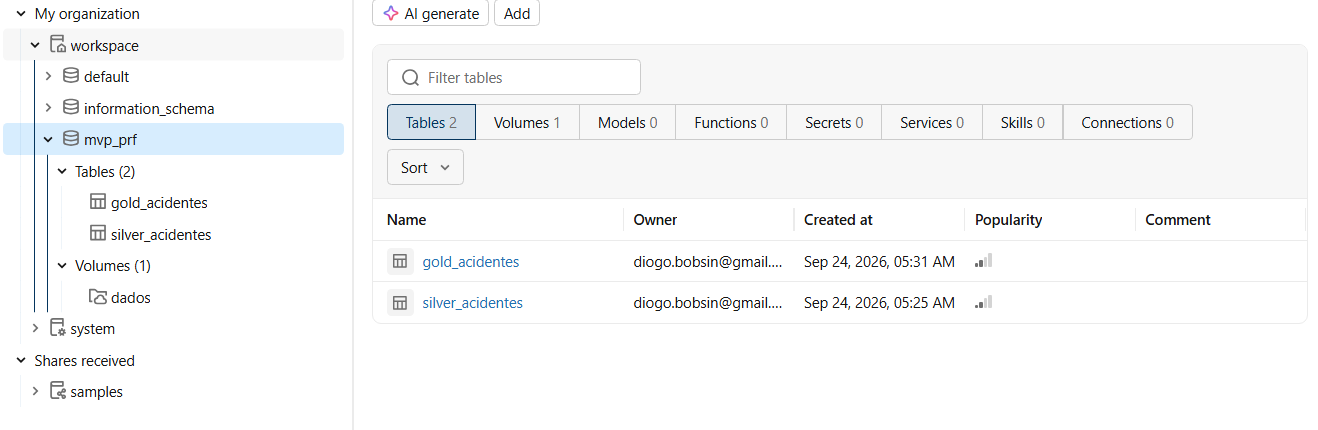

In [0]:
import base64

caminho_imagem = "/Volumes/workspace/mvp_prf/dados/evidencias/catalogo_databricks.png"

with open(caminho_imagem, "rb") as arquivo:
    imagem_base64 = base64.b64encode(arquivo.read()).decode("utf-8")

displayHTML(
    f"""
    <div style="text-align:center;">
        <img src="data:image/png;base64,{imagem_base64}"
             style="max-width:100%; height:auto;">
        <p style="font-style:italic;">
            Estrutura de armazenamento do projeto no Databricks,
            apresentando o schema mvp_prf, as tabelas Delta das camadas Silver
            e Gold e o Volume utilizado para armazenamento dos dados da camada Bronze.
        </p>
    </div>
    """
)

## 8. Arquitetura do Pipeline de Dados

O pipeline foi desenvolvido integralmente no ambiente Databricks, utilizando uma arquitetura em camadas para separar os dados originais das etapas de tratamento e da camada destinada ao consumo analítico.

A arquitetura adotada segue o fluxo:

**Fontes públicas → Ingestão → Bronze → Transformação e integração → Silver → Enriquecimento → Gold → Análises**

Essa separação permite preservar os arquivos obtidos das fontes originais, executar as transformações de forma controlada e disponibilizar uma camada final preparada para responder às questões definidas no início do trabalho.


### 8.1 Camada Bronze

A camada Bronze preserva os dados obtidos das fontes externas em seu formato original.

Os dados de acidentes foram coletados a partir dos arquivos públicos disponibilizados pela Polícia Rodoviária Federal (PRF), utilizando os arquivos anuais agrupados por ocorrência referentes ao período de 2017 a 2025.

Também foi incorporado ao projeto o arquivo de feriados nacionais disponibilizado pela ANBIMA.

Os arquivos foram armazenados em um Volume no Databricks, mantendo uma separação entre as duas fontes:

- `bronze/prf/`: arquivos anuais de acidentes da PRF;
- `bronze/feriados/`: arquivo original de feriados da ANBIMA.

A preservação dos arquivos originais na camada Bronze permite manter uma referência da fonte utilizada antes da aplicação das transformações realizadas nas etapas posteriores.

Arquivos anuais da PRF armazenados na camada Bronze do Volume do projeto no Databricks.
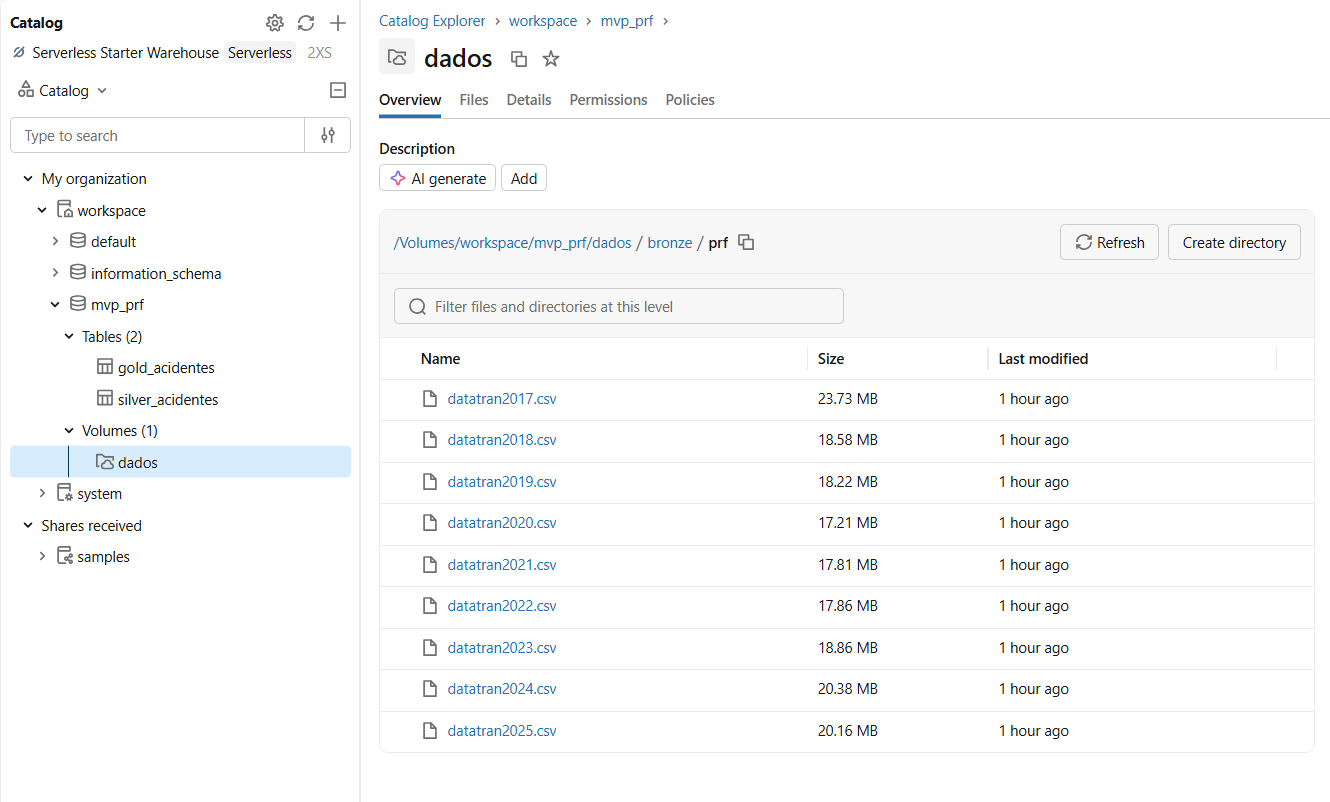

In [0]:
import base64

caminho_imagem = "/Volumes/workspace/mvp_prf/dados/evidencias/Arquivos_PRF.png"

with open(caminho_imagem, "rb") as arquivo:
    imagem_base64 = base64.b64encode(arquivo.read()).decode("utf-8")

displayHTML(
    f"""
    <div style="text-align:center;">
        <img src="data:image/png;base64,{imagem_base64}"
             style="max-width:100%; height:auto;">
        <p style="font-style:italic;">
            Arquivos anuais da PRF armazenados na camada Bronze do Volume do projeto no Databricks.
        </p>
    </div>
    """
)

### 8.2 Camada Silver

A camada Silver concentra as etapas de consolidação, limpeza e integração dos dados.

Os nove arquivos anuais da PRF foram lidos a partir da camada Bronze e consolidados em uma única estrutura. Durante essa etapa foi realizada a correção da codificação de caracteres dos arquivos, utilizando a codificação ISO-8859-1, necessária para preservar corretamente os caracteres acentuados existentes nos dados.

Também foram selecionados os atributos relevantes para os objetivos do trabalho e acrescentado o atributo `ano_origem`, utilizado para identificar o arquivo anual de origem de cada registro.

O arquivo de feriados da ANBIMA também passou por tratamento. Registros sem data válida, incluindo linhas informativas existentes no arquivo original, foram removidos e as datas foram padronizadas para permitir sua integração com os acidentes.

Por fim, os dados da PRF foram integrados ao calendário de feriados por meio da data da ocorrência. O resultado desse processo foi persistido como tabela Delta `silver_acidentes` no Databricks.

### 8.3 Camada Gold

A camada Gold foi construída a partir da tabela Silver e representa a estrutura preparada para consumo analítico.

Nessa etapa foram criados atributos derivados necessários para responder às questões do estudo, incluindo:

- ano, mês e hora da ocorrência;
- região geográfica derivada da Unidade da Federação;
- indicador de ocorrência com vítima fatal;
- indicador de ocorrência em feriado;
- identificação das semanas que possuem feriado nacional;
- indicador do período adotado como proxy de férias.

A tabela resultante foi persistida em formato Delta como `gold_acidentes` e utilizada como fonte para todas as análises apresentadas neste trabalho.

Essa abordagem mantém separadas as etapas de ingestão, tratamento e consumo analítico, evitando que as análises sejam executadas diretamente sobre os arquivos brutos.

### 8.4 Visão Consolidade da Arquitetura

Arquitetura do Pipeline.
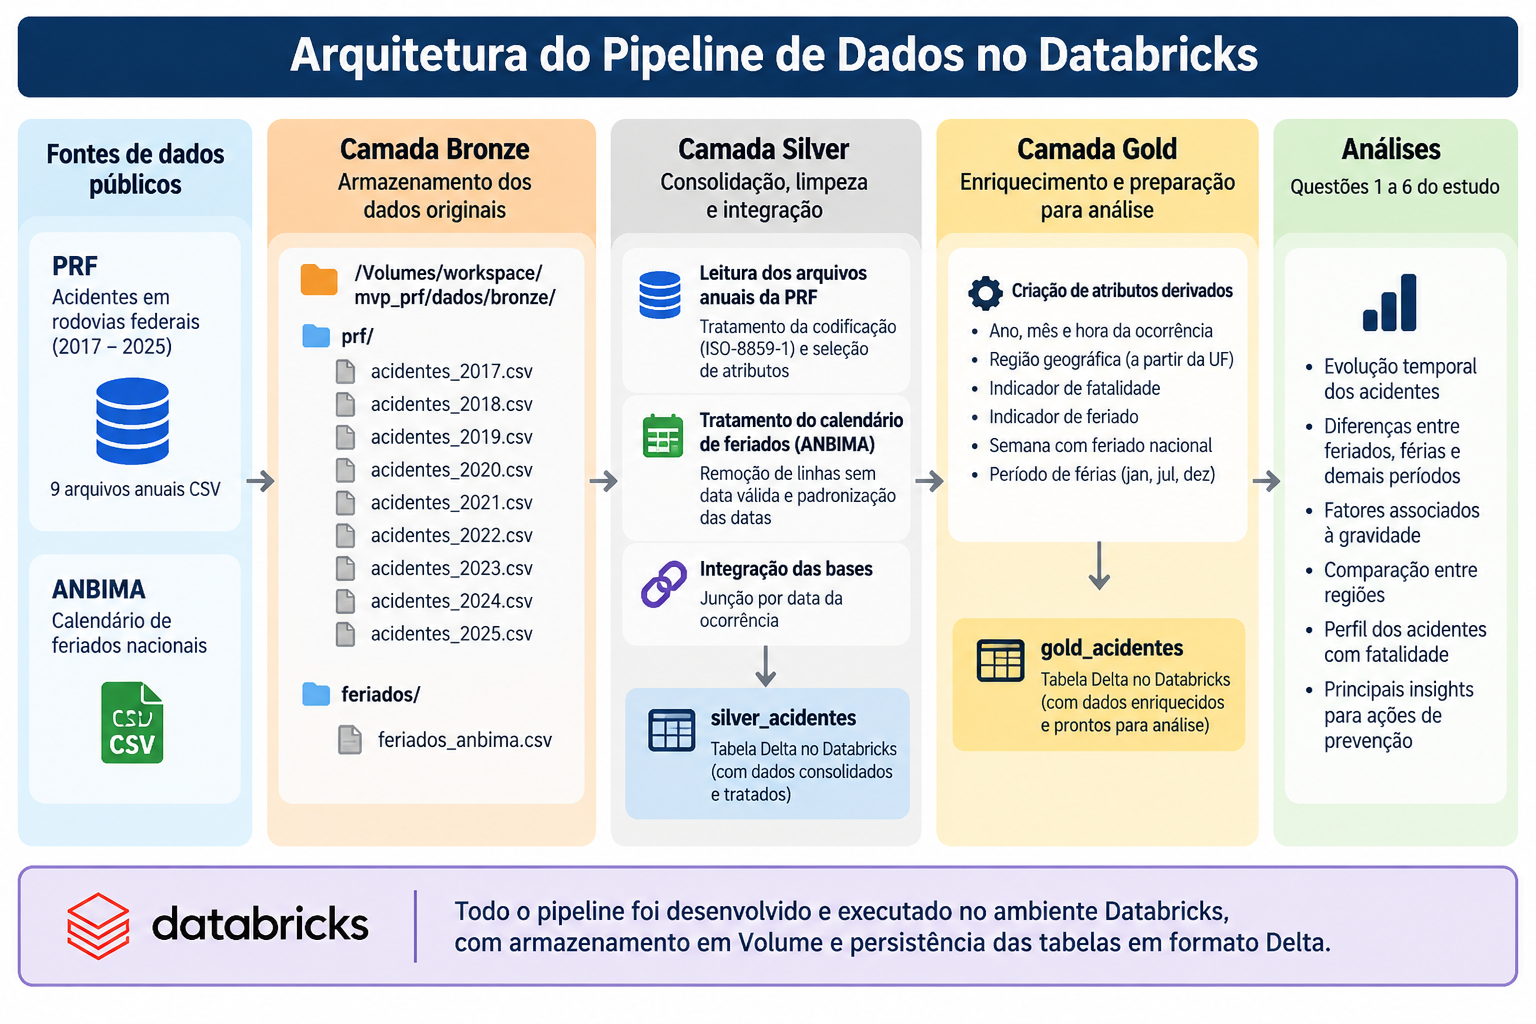

In [0]:
import base64

caminho_imagem = "/Volumes/workspace/mvp_prf/dados/evidencias/Arquitetura.png"

with open(caminho_imagem, "rb") as arquivo:
    imagem_base64 = base64.b64encode(arquivo.read()).decode("utf-8")

displayHTML(
    f"""
    <div style="text-align:center;">
        <img src="data:image/png;base64,{imagem_base64}"
             style="max-width:100%; height:auto;">
        <p style="font-style:italic;">
            Arquitetura do Pipeline.
        </p>
    </div>
    """
)

## 9. Autoavaliação

### Objetivos alcançados

Considero que os objetivos propostos para o MVP foram atingidos. Foi desenvolvido um pipeline de dados em ambiente de nuvem utilizando o Databricks, abrangendo as etapas de coleta, armazenamento, tratamento, integração, enriquecimento e análise dos dados.

A utilização da arquitetura em camadas Bronze, Silver e Gold permitiu preservar os arquivos originais, separar as etapas de tratamento e disponibilizar uma estrutura final preparada para análise. A integração dos dados de acidentes da PRF com o calendário de feriados da ANBIMA também permitiu enriquecer a base original e criar novos atributos para responder às questões definidas no início do trabalho.

As seis questões propostas foram analisadas, permitindo avaliar a evolução histórica dos acidentes, sua sazonalidade, distribuição regional, taxa de fatalidade, principais causas e tipos de acidentes e as condições associadas às ocorrências.

### Dificuldades encontradas

As principais dificuldades estiveram relacionadas à coleta e preparação de dados provenientes de fontes diferentes. Os arquivos da PRF exigiram tratamento específico de codificação de caracteres, enquanto o arquivo de feriados da ANBIMA apresentou registros informativos sem datas válidas, que precisaram ser identificados durante a preparação dos dados.

Outro desafio foi estruturar o processo de forma que os dados brutos fossem preservados e as diferentes etapas de transformação permanecessem claramente separadas. A utilização das camadas Bronze, Silver e Gold contribuiu para organizar esse processo e facilitar a rastreabilidade entre os dados originais e aqueles utilizados nas análises.

### Trabalhos futuros

Como evolução do projeto, poderiam ser incorporadas novas fontes de dados relacionadas à malha rodoviária, fluxo de veículos e características das rodovias. Essas informações permitiriam criar indicadores normalizados pela exposição ao tráfego e aprofundar a investigação das diferenças observadas entre regiões, tipos de pista e condições das ocorrências.

Também seria possível automatizar a atualização do pipeline para incorporar novos arquivos publicados pela PRF e ampliar o período histórico analisado.